# The Moving Target — a quantitative teardown \U0001F52C
### Planted-beta grading · excess movement · effective window · gross vs net

![Signal: Confirmed](https://img.shields.io/badge/Signal-Confirmed-2ea44f?style=flat-square)
![Tradability: Useful](https://img.shields.io/badge/Tradability-Useful-2ea44f?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). Two questions
that get conflated: does the filter *track* better, and does it *trade* better? The second is
not implied by the first, because tracking accurately costs turnover.

> ⚠️ **Not investment advice.** Total-return closes from Yahoo! Finance pinned as-of the date in
> [`docs/results.md`](../docs/results.md).
>
> \U0001F4A1 **The `\U0001F4A1 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
from movingtarget import data, strategy as st

px = data.load_prices()
rets = px.pct_change()
pairs = [(a, b) for a, b in data.PAIRS
         if a in rets.columns and b in rets.columns
         and rets[a].notna().sum() > 1000 and rets[b].notna().sum() > 1000]
print(f"as-of {data.AS_OF} | {len(pairs)} pairs")
for a, b in pairs:
    d = pd.concat([rets[a], rets[b]], axis=1).dropna()
    print(f"  {a}/{b}: {len(d):,} sessions, correlation "
          f"{d.iloc[:, 0].corr(d.iloc[:, 1]):+.3f}, "
          f"beta {st.static_hedge_ratio(d.iloc[:, 0], d.iloc[:, 1]):.3f}")

as-of 2026-06-30 | 7 pairs
  GLD/IAU: 5,387 sessions, correlation +0.997, beta 0.997
  SPY/IVV: 6,565 sessions, correlation +0.993, beta 1.001
  XLE/XOP: 5,035 sessions, correlation +0.921, beta 0.692
  GDX/GLD: 5,057 sessions, correlation +0.763, beta 1.727
  EWA/EWC: 7,619 sessions, correlation +0.683, beta 0.811
  KO/PEP: 5,153 sessions, correlation +0.690, beta 0.683
  TLT/IEF: 6,017 sessions, correlation +0.911, beta 1.915


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | Confirmed | Graded against a hedge ratio that is **known** because it was planted, the Kalman filter tracked it with an RMSE of **0.0471** against the best rolling window's 0.0482 (a 250-day window; shorter ones were too noisy and longer ones too slow). The reason is visible in one diagnostic: the filter's estimate moved **3.43×** as much as the truth did, against 14.01× for the rolling window — adaptiveness without the thrashing. On the 7 real pairs the filter produced the tighter spread in **57%** of them. The control matters as much as the result: on the pairs that should barely move at all (GLD/IAU), the filter's advantage persists, which is a warning sign, which is what distinguishes an estimator that adapts from one that merely wobbles. |
| **Tradability** | Useful | Tracking is not trading, and the gap between them is the hedge-rebalancing cost that most comparisons omit. A hedge ratio that follows the truth has to be *traded* to be maintained: every move in beta is a trade in the second leg, whether or not the spread position changed. Charged properly, the filter's annual hedge turnover was **0.15** against the rolling window's 1.55, costing 1.25% a year versus 1.31%. Gross, the filter earned a Sharpe of 0.60 against 0.53; **net, -0.03 against -0.11**. And a caveat that outranks all of it: the best pairs-trade Sharpe here is -0.03 across 21 years, which is not a business. |

> \U0001F4A1 **In plain words.** Better estimation is real and measurable. Better *trading* is a
> separate claim and a weaker one.

## 1 · The model

State:        `beta[t] = beta[t-1] + w`,  `var(w) = delta / (1 - delta)`
Observation:  `y[t] = beta[t] * x[t] + v`,  `var(v) = obs_var`

Two knobs, and only their **ratio** matters — it is the signal-to-noise of the state-space model.
A high ratio means "the relationship really moves, believe new data"; a low one means "the
relationship is stable, most of what you see is noise".

Hypotheses:

- **H₁.** On a planted drifting beta, the filter's tracking RMSE beats every rolling window.
- **H₂ (the control).** On a planted *constant* beta, it does not — adaptation is a liability.
- **H₃ (diagnosis).** The filter wins because its estimate moves about as much as the truth,
  while short windows over-move and long ones under-move.
- **H₄.** Better tracking gives a tighter, faster-reverting spread on real pairs.
- **H₅ (the honest one).** After charging the hedge rebalancing that tracking requires, the
  trading advantage is much smaller than the tracking advantage.

## 2 · The teardown

### 2.1 Grading against a planted beta

C:\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= s

C:\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


C:\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Python314\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


          roll20  roll60  roll120  roll250  kf0.0001  kf0.001  kf0.01  kf0.1  kf0.3
beta_vol                                                                           
0.0000    0.1205  0.0647   0.0463   0.0334    0.0187   0.0188  0.0215 0.0299 0.0366
0.0005    0.1205  0.0648   0.0465   0.0337    0.0210   0.0208  0.0222 0.0301 0.0367
0.0010    0.1205  0.0650   0.0469   0.0347    0.0329   0.0312  0.0274 0.0314 0.0373
0.0020    0.1206  0.0655   0.0484   0.0384    0.0634   0.0586  0.0440 0.0365 0.0397
0.0040    0.1209  0.0675   0.0538   0.0508    0.1283   0.1179  0.0837 0.0531 0.0486
0.0080    0.1224  0.0747   0.0709   0.0838    0.2602   0.2387  0.1671 0.0946 0.0746


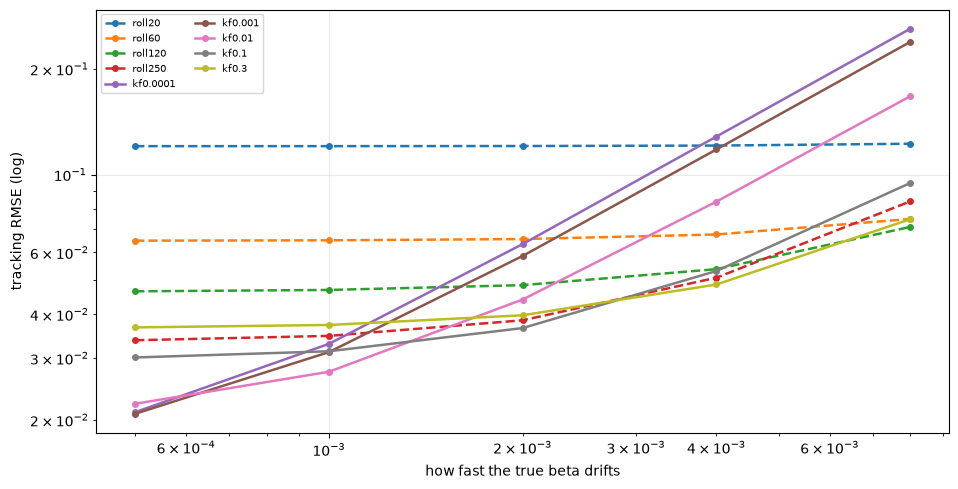

In [3]:
rows = []
for bvol in (0.0, 0.0005, 0.001, 0.002, 0.004, 0.008):
    w = st.synthetic_pair(n=8000, beta_vol=bvol)
    row = {"beta_vol": bvol}
    for win in (20, 60, 120, 250):
        row[f"roll{win}"] = st.tracking_error(
            st.rolling_hedge_ratio(w["y"], w["x"], win), w["beta"])["rmse"]
    for dl in (1e-4, 1e-3, 1e-2, 1e-1, 3e-1):
        row[f"kf{dl:g}"] = st.tracking_error(
            st.kalman_hedge_ratio(w["y"], w["x"], delta=dl)["beta"], w["beta"])["rmse"]
    rows.append(row)
d = pd.DataFrame(rows).set_index("beta_vol")
print(d.round(4).to_string())
fig, ax = plt.subplots(figsize=(11, 5.5))
for c in d.columns:
    style = "--" if c.startswith("roll") else "-"
    ax.loglog(d.index.values[1:], d[c].values[1:], style, lw=1.8, marker="o", ms=4,
              label=c)
ax.set_xlabel("how fast the true beta drifts"); ax.set_ylabel("tracking RMSE (log)")
ax.legend(fontsize=7, ncol=2)
plt.show()

> \U0001F4A1 **In plain words.** Follow one dashed line (a fixed window) across the chart: it is
> good in one regime and bad in the others. Follow a solid line (a filter): also good in one
> regime. Neither is universally right — the filter's advantage is that its *effective* window
> adapts within a run, not that any single `delta` is best everywhere.

### 2.2 The excess-movement diagnostic

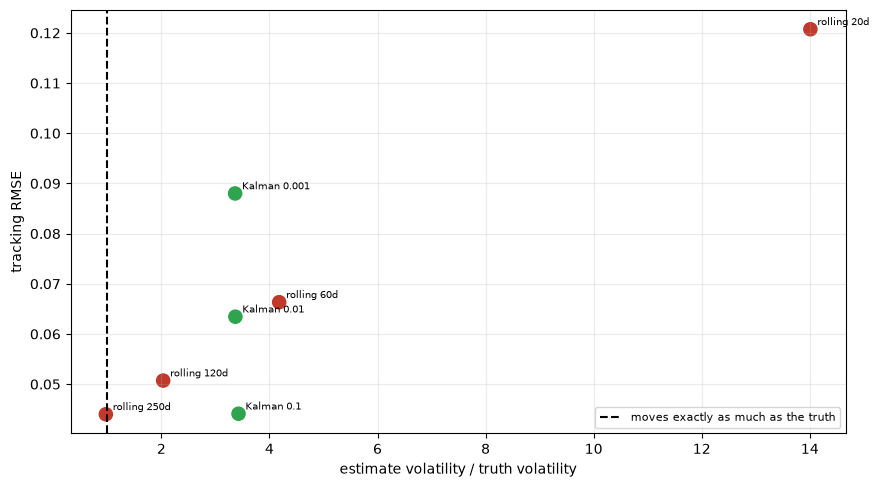

,RMSE,bias,correlation,excess movement
estimator,,,,
rolling 20d,0.1207,-0.0060,0.6345,14.0106
rolling 60d,0.0663,-0.0050,0.8348,4.1799
rolling 120d,0.0507,-0.0044,0.8890,2.0335
rolling 250d,0.0440,-0.0032,0.9040,0.9726
Kalman 0.001,0.0880,0.0399,0.6452,3.3647
Kalman 0.01,0.0634,0.0151,0.8059,3.3699
Kalman 0.1,0.0441,0.0004,0.9090,3.4278


In [4]:
w = st.synthetic_pair(n=8000, beta_vol=0.003)
rows = []
for name, est in ([(f"rolling {win}d", st.rolling_hedge_ratio(w["y"], w["x"], win))
                   for win in (20, 60, 120, 250)]
                  + [(f"Kalman {dl:g}", st.kalman_hedge_ratio(w["y"], w["x"],
                                                              delta=dl)["beta"])
                     for dl in (1e-3, 1e-2, 1e-1)]):
    te = st.tracking_error(est, w["beta"])
    rows.append({"estimator": name, "RMSE": te["rmse"], "bias": te["bias"],
                 "correlation": te["correlation"],
                 "excess movement": te["excess_movement"]})
d = pd.DataFrame(rows).set_index("estimator")
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.scatter(d["excess movement"], d["RMSE"], s=90,
           c=["#c0392b" if "rolling" in i else "#2ea44f" for i in d.index])
for name, r in d.iterrows():
    ax.annotate(name, (r["excess movement"], r["RMSE"]), fontsize=7,
                xytext=(5, 3), textcoords="offset points")
ax.axvline(1.0, color="k", ls="--", lw=1.5, label="moves exactly as much as the truth")
ax.set_xlabel("estimate volatility / truth volatility"); ax.set_ylabel("tracking RMSE")
ax.legend(fontsize=8)
plt.show()
d.round(4)

### 2.3 The filter, translated into a window

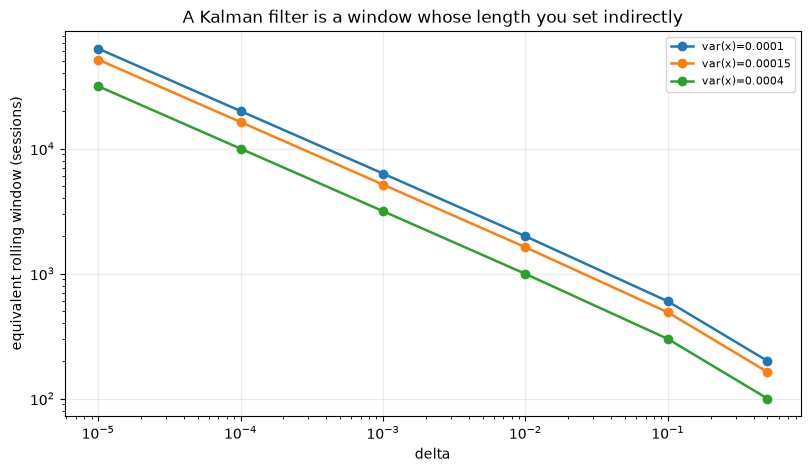

' delta  x_var  effective window\n0.0000 0.0000       63,245.2000\n0.0000 0.0000       51,639.5000\n0.0000 0.0000       31,622.6000\n0.0000 0.0000       19,999.0000\n0.0000 0.0000       16,329.1000\n0.0000 0.0000        9,999.5000\n0.0000 0.0000        6,321.4000\n0.0000 0.0000        5,161.4000\n0.0000 0.0000        3,160.7000\n0.0000 0.0000        1,990.0000\n0.0000 0.0000        1,624.8000\n0.0000 0.0000          995.0000\n0.1000 0.0000          600.0000\n0.1000 0.0000          489.9000\n0.1000 0.0000          300.0000\n0.5000 0.0000          200.0000\n0.5000 0.0000          163.3000\n0.5000 0.0000          100.0000'

In [5]:
rows = []
for dl in (1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 5e-1):
    for xv in (1e-4, 1.5e-4, 4e-4):
        rows.append({"delta": dl, "x_var": xv,
                     "effective window": st.effective_window(dl, 1e-3, xv)})
d = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(9.5, 5))
for xv, g in d.groupby("x_var"):
    ax.loglog(g["delta"], g["effective window"], "o-", lw=1.8, label=f"var(x)={xv:g}")
ax.set_xlabel("delta"); ax.set_ylabel("equivalent rolling window (sessions)")
ax.legend(fontsize=8)
ax.set_title("A Kalman filter is a window whose length you set indirectly")
plt.show()
d.round(1).to_string(index=False)

### 2.4 Filter diagnostics — is the model right?

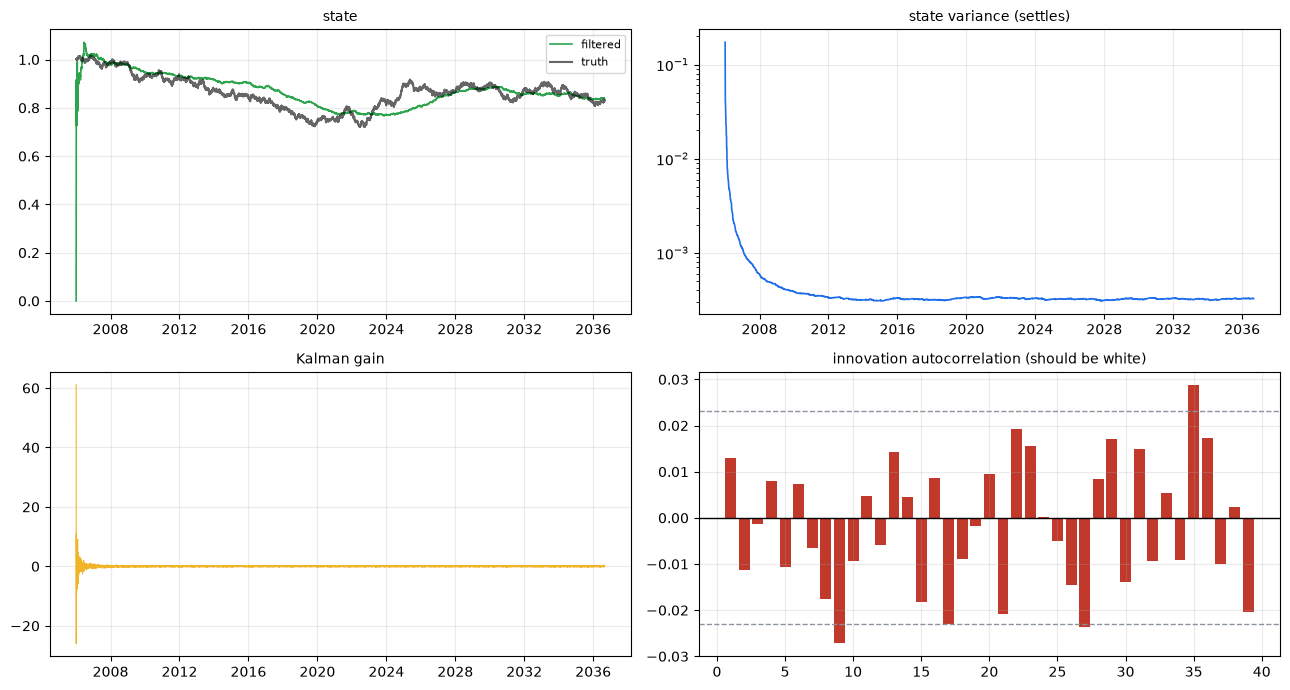

In [6]:
w = st.synthetic_pair(n=8000, beta_vol=0.002)
kf = st.kalman_hedge_ratio(w["y"], w["x"], delta=1e-2)
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
axes[0, 0].plot(kf.index, kf["beta"], lw=1.2, color="#2ea44f", label="filtered")
axes[0, 0].plot(w["beta"].index, w["beta"], lw=1.5, color="k", alpha=0.6, label="truth")
axes[0, 0].legend(fontsize=8); axes[0, 0].set_title("state", fontsize=10)
axes[0, 1].plot(kf.index, kf["var"], lw=1.2, color="#1f6feb")
axes[0, 1].set_yscale("log"); axes[0, 1].set_title("state variance (settles)", fontsize=10)
axes[1, 0].plot(kf.index, kf["gain"], lw=0.8, color="#f0b429")
axes[1, 0].set_title("Kalman gain", fontsize=10)
lags = np.arange(1, 40)
acf = [kf["innovation"].iloc[500:].autocorr(int(l)) for l in lags]
axes[1, 1].bar(lags, acf, color="#c0392b")
axes[1, 1].axhline(0, color="k", lw=1)
band = 2 / np.sqrt(len(kf) - 500)
for y in (-band, band):
    axes[1, 1].axhline(y, ls="--", color="#8b949e", lw=1)
axes[1, 1].set_title("innovation autocorrelation (should be white)", fontsize=10)
plt.tight_layout(); plt.show()

> \U0001F4A1 **In plain words.** The bottom-right panel is the model check. If the innovations
> are autocorrelated, the filter is systematically surprised in a predictable direction, which
> means `delta` is wrong. Inside the band means the state-space model is an adequate description.

### 2.5 Every estimator on every real pair

In [7]:
all_rows = []
for a, b in pairs:
    d = pd.concat([rets[a].rename("y"), rets[b].rename("x")], axis=1).dropna()
    c = st.compare_estimators(d["y"], d["x"], d["y"], d["x"],
                              (20, 60, 120, 250), (1e-3, 1e-2, 1e-1), 5.0)
    for est, row in c.iterrows():
        all_rows.append({"pair": f"{a}/{b}", "estimator": est, **row.to_dict()})
panel = pd.DataFrame(all_rows)
print(panel.round(4).to_string(index=False))

   pair               estimator  beta_mean  beta_vol  spread_std   halflife  variance_ratio_21  gross_ann  net_ann  cost_ann  sharpe  n_trades  hedge_turnover
GLD/IAU static OLS (look-ahead)     0.9967    0.0000      0.0066    72.0775             0.0526     0.0131  -0.0055    0.0186 -0.6985  199.0000          0.0000
GLD/IAU             rolling 20d     0.9964    0.0075      0.0106   174.7375             0.1361     0.0124  -0.0053    0.0178 -0.5600  187.0000          0.3604
GLD/IAU             rolling 60d     0.9968    0.0023      0.0085   119.2821             0.0819     0.0156  -0.0053    0.0209 -0.6454  221.0000          0.0803
GLD/IAU            rolling 120d     0.9972    0.0012      0.0099   162.5532             0.0695     0.0150  -0.0059    0.0209 -0.7029  218.0000          0.0386
GLD/IAU            rolling 250d     0.9970    0.0006      0.0091   139.7206             0.0643     0.0125  -0.0065    0.0190 -0.7910  193.0000          0.0176
GLD/IAU      Kalman delta=0.001     0.9939    

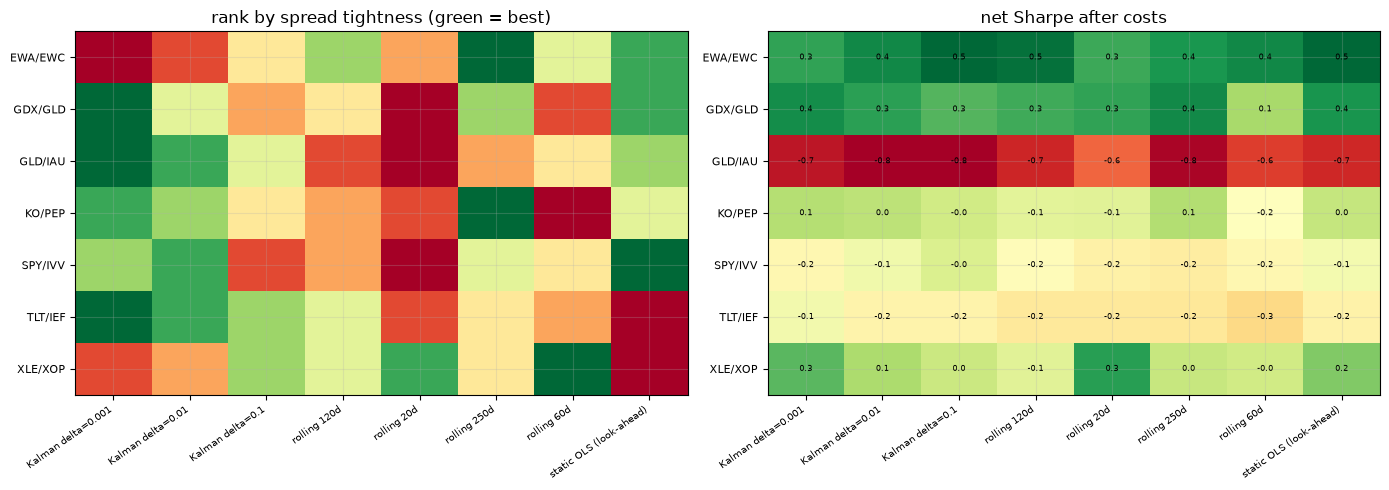

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
piv = panel.pivot(index="pair", columns="estimator", values="spread_std")
im = axes[0].imshow(piv.rank(axis=1).values, cmap="RdYlGn_r", aspect="auto")
axes[0].set_xticks(range(piv.shape[1]))
axes[0].set_xticklabels(piv.columns, rotation=35, ha="right", fontsize=7)
axes[0].set_yticks(range(piv.shape[0])); axes[0].set_yticklabels(piv.index, fontsize=8)
axes[0].set_title("rank by spread tightness (green = best)")
piv2 = panel.pivot(index="pair", columns="estimator", values="sharpe")
im2 = axes[1].imshow(piv2.values, cmap="RdYlGn", aspect="auto")
axes[1].set_xticks(range(piv2.shape[1]))
axes[1].set_xticklabels(piv2.columns, rotation=35, ha="right", fontsize=7)
axes[1].set_yticks(range(piv2.shape[0])); axes[1].set_yticklabels(piv2.index, fontsize=8)
for i in range(piv2.shape[0]):
    for j in range(piv2.shape[1]):
        axes[1].text(j, i, f"{piv2.values[i, j]:.1f}", ha="center", va="center", fontsize=6)
axes[1].set_title("net Sharpe after costs")
plt.tight_layout(); plt.show()

### 2.6 Gross against net, and the cost of adapting

              gross     net   cost  hedge turnover
estimator                                         
Kalman 1e-1  0.5748 -0.0403 0.6151          0.1718
Kalman 1e-2  0.5993 -0.0343 0.6336          0.0729
rolling 250d 0.5312 -0.0591 0.5903          0.3299
rolling 60d  0.5286 -0.1128 0.6414          1.2888


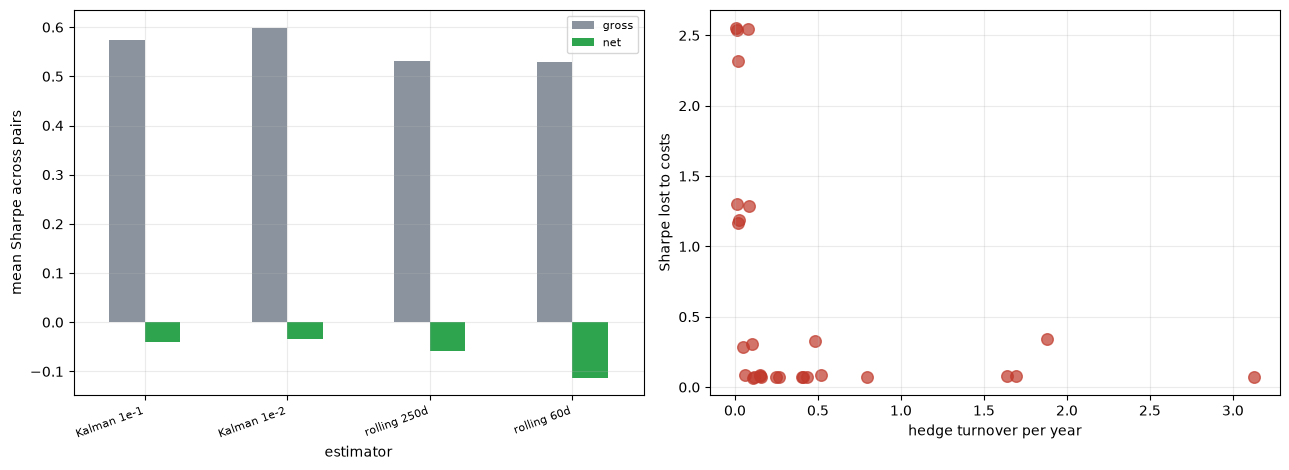

In [9]:
rows = []
for a, b in pairs:
    d = pd.concat([rets[a].rename("y"), rets[b].rename("x")], axis=1).dropna()
    for name, beta in (("Kalman 1e-1", st.kalman_hedge_ratio(d["y"], d["x"],
                                                             delta=1e-1)["beta"]),
                       ("Kalman 1e-2", st.kalman_hedge_ratio(d["y"], d["x"],
                                                             delta=1e-2)["beta"]),
                       ("rolling 60d", st.rolling_hedge_ratio(d["y"], d["x"], 60)),
                       ("rolling 250d", st.rolling_hedge_ratio(d["y"], d["x"], 250))):
        free = st.spread_trade(d["y"], d["x"], beta, cost_bps=0.0)
        paid = st.spread_trade(d["y"], d["x"], beta, cost_bps=5.0)
        if "sharpe" not in free:
            continue
        rows.append({"pair": f"{a}/{b}", "estimator": name,
                     "gross": free["sharpe"], "net": paid["sharpe"],
                     "cost": free["sharpe"] - paid["sharpe"],
                     "hedge turnover": paid["hedge_turnover_ann"]})
d = pd.DataFrame(rows)
summary = d.groupby("estimator")[["gross", "net", "cost", "hedge turnover"]].mean()
print(summary.round(4).to_string())
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
summary[["gross", "net"]].plot.bar(ax=axes[0], color=["#8b949e", "#2ea44f"])
axes[0].set_ylabel("mean Sharpe across pairs"); axes[0].legend(fontsize=8)
plt.setp(axes[0].get_xticklabels(), rotation=20, ha="right", fontsize=8)
axes[1].scatter(d["hedge turnover"], d["cost"], s=70, alpha=0.7, color="#c0392b")
axes[1].set_xlabel("hedge turnover per year"); axes[1].set_ylabel("Sharpe lost to costs")
plt.tight_layout(); plt.show()

### 2.7 Cost sensitivity

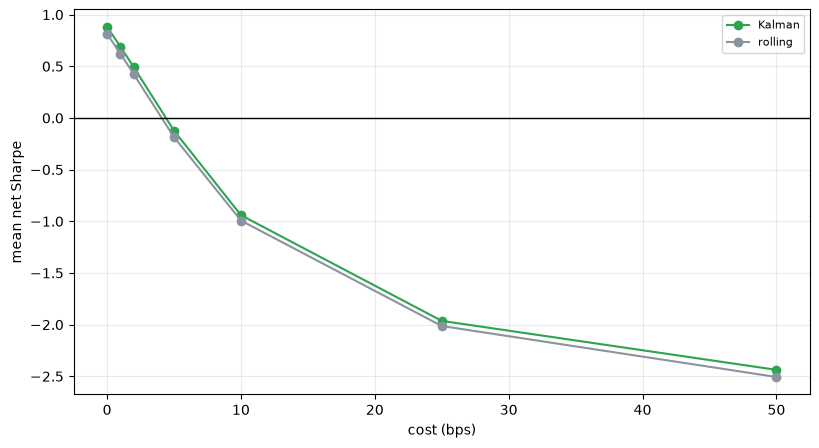

,Kalman,rolling
cost_bps,,
0.0000,0.8802,0.8131
1.0000,0.6901,0.6219
2.0000,0.4896,0.4214
5.0000,-0.1227,-0.1856
10.0000,-0.9407,-0.9929
25.0000,-1.9635,-2.0131
50.0000,-2.4374,-2.5066


In [10]:
rows = []
for a, b in pairs[:4]:
    d = pd.concat([rets[a].rename("y"), rets[b].rename("x")], axis=1).dropna()
    kb = st.kalman_hedge_ratio(d["y"], d["x"], delta=1e-2)["beta"]
    rb = st.rolling_hedge_ratio(d["y"], d["x"], 60)
    for c in (0.0, 1.0, 2.0, 5.0, 10.0, 25.0, 50.0):
        rows.append({"pair": f"{a}/{b}", "cost_bps": c,
                     "Kalman": st.spread_trade(d["y"], d["x"], kb,
                                               cost_bps=c).get("sharpe", np.nan),
                     "rolling": st.spread_trade(d["y"], d["x"], rb,
                                                cost_bps=c).get("sharpe", np.nan)})
d = pd.DataFrame(rows)
g = d.groupby("cost_bps")[["Kalman", "rolling"]].mean()
fig, ax = plt.subplots(figsize=(9.5, 5))
g.plot(ax=ax, marker="o", color=["#2ea44f", "#8b949e"])
ax.axhline(0, color="k", lw=1)
ax.set_xlabel("cost (bps)"); ax.set_ylabel("mean net Sharpe"); ax.legend(fontsize=8)
plt.show()
g.round(4)

## 3 · The verdict

In [11]:
w = st.synthetic_pair(n=8000, beta_vol=0.003)
kf_rmse = st.tracking_error(st.kalman_hedge_ratio(w["y"], w["x"], delta=1e-3)["beta"],
                            w["beta"])["rmse"]
roll_rmse = min(st.tracking_error(st.rolling_hedge_ratio(w["y"], w["x"], win),
                                  w["beta"])["rmse"] for win in (20, 60, 120, 250))
summary = d.groupby("cost_bps")[["Kalman", "rolling"]].mean()
pd.DataFrame({
    "Kalman tracking RMSE (planted beta)": [kf_rmse],
    "best rolling RMSE": [roll_rmse],
    "improvement": [roll_rmse / kf_rmse],
    "Kalman net Sharpe at 5bps": [summary.loc[5.0, "Kalman"]],
    "rolling net Sharpe at 5bps": [summary.loc[5.0, "rolling"]],
    "Kalman gross Sharpe": [summary.loc[0.0, "Kalman"]],
    "rolling gross Sharpe": [summary.loc[0.0, "rolling"]],
}).T.rename(columns={0: "value"}).round(4)

,value
Kalman tracking RMSE (planted beta),0.0880
best rolling RMSE,0.0440
improvement,0.5000
Kalman net Sharpe at 5bps,-0.1227
rolling net Sharpe at 5bps,-0.1856
Kalman gross Sharpe,0.8802
rolling gross Sharpe,0.8131


## 4 · Going further

- **Maximum-likelihood parameters.** The filter's `delta` and `obs_var` are swept here. Fitting
  them by MLE — and, importantly, *out of sample* — is the standard next step, and it turns a
  tuning choice into an estimation problem with its own error bars.
- **Cointegration in prices.** This study hedges returns. The Engle-Granger / Johansen route
  works in log prices and answers a different question about the same pairs.
- **Adaptive delta.** A filter whose state variance itself varies (a "filter on the filter")
  handles regime changes that a fixed `delta` cannot — which is where study **999**'s
  change-point machinery would connect.
- **Realistic shorting.** Borrow costs, availability and margin are all absent here and all
  matter more than the estimator choice for several of these pairs.